In [3]:
%%capture
!pip install wfdb torchinfo

In [4]:
import sys
from pathlib import Path
from joblib import Parallel, delayed
from tqdm import tqdm

import numpy as np
import scipy as sp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import *

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

import wfdb

In [5]:
#!/usr/bin/env python

# Do *not* edit this script.
# These are helper functions that you can use with your code.
# Check the example code to see how to use these functions in your code.

import numpy as np
import os
import scipy as sp
import sys
import wfdb

### Challenge variables
patient_id_string = '# Patient ID:'
encounter_id_string = '# Encounter ID:'
age_string = '# Age:'
sex_string = '# Sex:'
label_string = '# Chagas label:'
probability_string = '# Chagas probability:'

### Challenge data I/O functions

# Find the records in a folder and its subfolders.
def find_records(folder, header_extension='.hea'):
    records = set()
    for root, directories, files in os.walk(folder):
        for file in files:
            extension = os.path.splitext(file)[1]
            if extension == header_extension:
                record = os.path.relpath(os.path.join(root, file), folder)[:-len(header_extension)]
                records.add(record)
    records = sorted(records)
    return records

# Load the header for a record.
def load_header(record):
    header_file = get_header_file(record)
    header = load_text(header_file)
    return header

# Load the signals for a record.
def load_signals(record):
    signal, fields = wfdb.rdsamp(record)
    return signal, fields

# Load the label for a record.
def load_label(record):
    header = load_header(record)
    label = get_label(header)
    return label

# Load the probability for a record.
def load_probability(record):
    header = load_header(record)
    label = get_probability(header)
    return label

# Save the model outputs for a record.
def save_outputs(output_file, record_name, label, probability):
    output_string = f'{record_name}\n{label_string} {label}\n{probability_string} {probability}\n'
    save_text(output_file, output_string)
    return output_string

### Helper Challenge functions

# Load a text file as a string.
def load_text(filename):
    with open(filename, 'r') as f:
        string = f.read()
    return string

# Save a string as a text file.
def save_text(filename, string):
    with open(filename, 'w') as f:
        f.write(string)

# Get a variable from a string.
def get_variable(string, variable_name):
    variable = ''
    has_variable = False
    for l in string.split('\n'):
        if l.startswith(variable_name):
            variable = l[len(variable_name):].strip()
            has_variable = True
    return variable, has_variable

# Get the header file for a record.
def get_header_file(record):
    if not record.endswith('.hea'):
        header_file = record + '.hea'
    else:
        header_file = record
    return header_file

# Get the signal files for a record.
def get_signal_files(record):
    header_file = get_header_file(record)
    if os.path.isfile(header_file):
        header = load_text(header_file)
        signal_files = get_signal_files_from_header(header)
    else:
        signal_files = list()
    return signal_files

def get_signal_files_from_header(string):
    signal_files = list()
    for i, l in enumerate(string.split('\n')):
        arrs = [arr.strip() for arr in l.split(' ')]
        if i==0 and not l.startswith('#'):
            num_channels = int(arrs[1])
        elif i<=num_channels and not l.startswith('#'):
            signal_file = arrs[0]
            if signal_file not in signal_files:
                signal_files.append(signal_file)
        else:
            break
    return signal_files

# Get the patient ID from a header or a similar string.
def get_patient_id(string):
    patient_id, has_patient_id = get_variable(string, patient_id_string)
    if not has_patient_id:
        patient_id = float('nan')
    return patient_id

# Get the encounter ID from a header or a similar string.
def get_patient_id(string):
    encounter_id, has_encounter_id = get_variable(string, encounter_id_string)
    if not has_encounter_id:
        encounter_id = float('nan')
    return encounter_id

# Get the age from a header or a similar string.
def get_age(string):
    age, has_age = get_variable(string, age_string)
    if not has_age:
        age = float('nan')
    elif is_number(age):
        age = float(age)
    return age

# Get the sex from a header or a similar string.
def get_sex(string):
    sex, has_sex = get_variable(string, sex_string)
    if not has_sex:
        sex = None
    return sex

# Get the label from a header or a similar string.
def get_label(string, allow_missing=False):
    label, has_label = get_variable(string, label_string)
    if not has_label and not allow_missing:
        raise Exception('No label is available: are you trying to load the labels from the held-out data?')
    label = sanitize_boolean_value(label)
    return label

# Get the probability from a header or a similar string.
def get_probability(string, allow_missing=False):
    probability, has_probability = get_variable(string, probability_string)
    if not has_probability and not allow_missing:
        raise Exception('No probability is available: are you trying to load the labels from the held-out data?')
    probability = sanitize_scalar_value(probability)
    return probability

### WFDB functions

# Get the record name from a header file.
def get_record_name(string):
    value = string.split('\n')[0].split(' ')[0].split('/')[0].strip()
    return value

# Get the number of signals from a header file.
def get_num_signals(string):
    value = string.split('\n')[0].split(' ')[1].strip()
    if is_integer(value):
        value = int(value)
    else:
        value = None
    return value

# Get the sampling frequency from a header file.
def get_sampling_frequency(string):
    value = string.split('\n')[0].split(' ')[2].split('/')[0].strip()
    if is_number(value):
        value = float(value)
    else:
        value = None
    return value

# Get the number of samples from a header file.
def get_num_samples(string):
    value = string.split('\n')[0].split(' ')[3].strip()
    if is_integer(value):
        value = int(value)
    else:
        value = None
    return value

# Get the signal names from a header file.
def get_signal_names(string):
    num_signals = get_num_signals(string)
    values = list()
    for i, l in enumerate(string.split('\n')):
        if 1 <= i <= num_signals:
            value = l.split(' ')[8]
            values.append(value)
    return values

### Evaluation functions

# Compute the Challenge score.
def compute_challenge_score(labels, outputs, max_fraction_positive = 0.05):
    # Check the data.
    assert len(labels) == len(outputs)
    num_instances = len(labels)
    max_num_positive_instances = int(max_fraction_positive * num_instances)

    # Convert the data to NumPy arrays, as needed, for easier indexing.
    labels = np.asarray(labels, dtype=np.float64)
    outputs = np.asarray(outputs, dtype=np.float64)

    # Collect the unique output values as the thresholds for the positive and negative classes.
    thresholds = np.unique(outputs)
    thresholds = np.append(thresholds, thresholds[-1] + 1)
    thresholds = thresholds[::-1]
    num_thresholds = len(thresholds)

    idx = np.argsort(outputs)[::-1]

    # Initialize the TPs, FPs, FNs, and TNs with no positive outputs.
    tp = np.zeros(num_thresholds)
    fp = np.zeros(num_thresholds)
    fn = np.zeros(num_thresholds)
    tn = np.zeros(num_thresholds)

    tp[0] = 0
    fp[0] = 0
    fn[0] = np.sum(labels == 1)
    tn[0] = np.sum(labels == 0)

    # Update the TPs, FPs, FNs, and TNs using the values at the previous threshold.
    i = 0
    for j in range(1, num_thresholds):
        tp[j] = tp[j-1]
        fp[j] = fp[j-1]
        fn[j] = fn[j-1]
        tn[j] = tn[j-1]

        while i < num_instances and outputs[idx[i]] >= thresholds[j]:
            if labels[idx[i]] == 1:
                tp[j] += 1
                fn[j] -= 1
            else:
                fp[j] += 1
                tn[j] -= 1
            i += 1

    # Find the true positive rate so that the number of positive model outputs are no more than 5% of the total instances.
    k = num_thresholds
    for j in range(1, num_thresholds):
        if tp[j] + fp[j] > max_num_positive_instances:
            k = j - 1
            break

    if tp[k] + fn[k] > 0:
        tpr = tp[k] / (tp[k] + fn[k])
    else:
        tpr = float('nan')

    return tpr

# Compute area under the receiver operating characteristic curve (AUROC) and area under the precision recall curve (AUPRC).
def compute_auc(labels, outputs):
    assert len(labels) == len(outputs)
    num_instances = len(labels)

    # Convert the data to NumPy arrays for easier indexing.
    labels = np.asarray(labels, dtype=np.float64)
    outputs = np.asarray(outputs, dtype=np.float64)

    # Collect the unique output values as the thresholds for the positive and negative classes.
    thresholds = np.unique(outputs)
    thresholds = np.append(thresholds, thresholds[-1]+1)
    thresholds = thresholds[::-1]
    num_thresholds = len(thresholds)

    idx = np.argsort(outputs)[::-1]

    # Initialize the TPs, FPs, FNs, and TNs with no positive outputs.
    tp = np.zeros(num_thresholds)
    fp = np.zeros(num_thresholds)
    fn = np.zeros(num_thresholds)
    tn = np.zeros(num_thresholds)

    tp[0] = 0
    fp[0] = 0
    fn[0] = np.sum(labels == 1)
    tn[0] = np.sum(labels == 0)

    # Update the TPs, FPs, FNs, and TNs using the values at the previous threshold.
    i = 0
    for j in range(1, num_thresholds):
        tp[j] = tp[j-1]
        fp[j] = fp[j-1]
        fn[j] = fn[j-1]
        tn[j] = tn[j-1]

        while i < num_instances and outputs[idx[i]] >= thresholds[j]:
            if labels[idx[i]] == 1:
                tp[j] += 1
                fn[j] -= 1
            else:
                fp[j] += 1
                tn[j] -= 1
            i += 1

    # Compute the TPRs, TNRs, and PPVs at each threshold.
    tpr = np.zeros(num_thresholds)
    tnr = np.zeros(num_thresholds)
    ppv = np.zeros(num_thresholds)
    for j in range(num_thresholds):
        if tp[j] + fn[j] > 0:
            tpr[j] = tp[j] / (tp[j] + fn[j])
        else:
            tpr[j] = float('nan')
        if fp[j] + tn[j] > 0:
            tnr[j] = tn[j] / (fp[j] + tn[j])
        else:
            tnr[j] = float('nan')
        if tp[j] + fp[j] > 0:
            ppv[j] = tp[j] / (tp[j] + fp[j])
        else:
            ppv[j] = float('nan')

    # Compute AUROC as the area under a piecewise linear function with TPR/sensitivity (x-axis) and TNR/specificity (y-axis) and
    # AUPRC as the area under a piecewise constant with TPR/recall (x-axis) and PPV/precision (y-axis).
    auroc = 0.0
    auprc = 0.0
    for j in range(num_thresholds-1):
        auroc += 0.5 * (tpr[j+1] - tpr[j]) * (tnr[j+1] + tnr[j])
        auprc += (tpr[j+1] - tpr[j]) * ppv[j+1]

    return auroc, auprc

# Compute the binary confusion matrix, where the columns are the expert labels and the rows are the classifier labels for the given
# classes.
def compute_confusion_matrix(labels, outputs):
    assert np.shape(labels) == np.shape(outputs)
    num_instances = len(labels)

    A = np.zeros((2, 2))
    for i in range(num_instances):
        if labels[i] == 1 and outputs[i] == 1:
            A[0, 0] += 1
        elif labels[i] == 1 and outputs[i] == 0:
            A[0, 1] += 1
        elif labels[i] == 0 and outputs[i] == 1:
            A[1, 0] += 1
        elif labels[i] == 0 and outputs[i] == 0:
            A[1, 1] += 1
        else:
            raise ValueError(f'{labels[i]} and/or {outputs[i]} not valid.')

    return A

# Compute accuracy.
def compute_accuracy(labels, outputs):
    # Compute the confusion matrix.
    A = compute_confusion_matrix(labels, outputs)

    # Compute accuracy.
    if np.sum(A) > 0:
        accuracy = np.trace(A) / np.sum(A)
    else:
        accuracy = float('nan')

    return accuracy

# Compute macro F-measure.
def compute_f_measure(labels, outputs):
    # Compute the confusion matrix.
    A = compute_confusion_matrix(labels, outputs)

    tp, fp, fn, tn = A[0, 0], A[0, 1], A[1, 0], A[1, 1]
    if 2 * tp + fp + fn > 0:
        f_measure = float(2 * tp) / float(2 * tp + fp + fn)
    else:
        f_measure = float('nan')

    return f_measure

# Normalize the channel names.
def normalize_names(names_ref, names_est):
    tmp = list()
    for a in names_est:
        for b in names_ref:
            if a.casefold() == b.casefold():
                tmp.append(b)
                break
    return tmp

# Reorder channels in signal.
def reorder_signal(input_signal, input_channels, output_channels):
    # Do not allow repeated channels with potentially different values in a signal.
    assert(len(set(input_channels)) == len(input_channels))
    assert(len(set(output_channels)) == len(output_channels))

    if input_channels == output_channels:
        output_signal = input_signal
    else:
        output_channels = normalize_names(input_channels, output_channels)

        input_signal = np.asarray(input_signal)
        num_samples = np.shape(input_signal)[0]
        num_channels = len(output_channels)
        data_type = input_signal.dtype

        output_signal = np.zeros((num_samples, num_channels), dtype=data_type)
        for i, output_channel in enumerate(output_channels):
            for j, input_channel in enumerate(input_channels):
                if input_channel == output_channel:
                    output_signal[:, i] = input_signal[:, j]

    return output_signal

### Other helper functions

# Remove any single or double quotes; parentheses, braces, and brackets (for singleton arrays); and spaces and tabs from a string.
def remove_extra_characters(x):
    x = str(x)
    x = x.replace('"', '').replace("'", "")
    x = x.replace('(', '').replace(')', '').replace('[', '').replace(']', '').replace('{', '').replace('}', '')
    x = x.replace(' ', '').replace('\t', '')
    x = x.strip()
    return x

# Check if a variable is a number or represents a number.
def is_number(x):
    try:
        float(x)
        return True
    except (ValueError, TypeError):
        return False

# Check if a variable is an integer or represents an integer.
def is_integer(x):
    if is_number(x):
        return float(x).is_integer()
    else:
        return False

# Check if a variable is a finite number or represents a finite number.
def is_finite_number(x):
    if is_number(x):
        return np.isfinite(float(x))
    else:
        return False

# Check if a variable is a NaN, i.e., not a number, or represents a NaN.
def is_nan(x):
    if is_number(x):
        return np.isnan(float(x))
    else:
        return False

# Check if a variable is a boolean or represents a boolean.
def is_boolean(x):
    if (is_number(x) and float(x)==0) or (remove_extra_characters(x).casefold() in ('false', 'f', 'no', 'n')):
        return True
    elif (is_number(x) and float(x)==1) or (remove_extra_characters(x).casefold() in ('true', 't', 'yes', 'y')):
        return True
    else:
        return False

# Sanitize integer values.
def sanitize_integer_value(x):
    x = remove_extra_characters(x)
    if is_integer(x):
        return int(float(x))
    else:
        return float('nan')

# Sanitize scalar values.
def sanitize_scalar_value(x):
    x = remove_extra_characters(x)
    if is_number(x):
        return float(x)
    else:
        return float('nan')

# Sanitize boolean values.
def sanitize_boolean_value(x):
    x = remove_extra_characters(x)
    if (is_number(x) and float(x)==0) or (remove_extra_characters(x).casefold() in ('false', 'f', 'no', 'n')):
        return 0
    elif (is_number(x) and float(x)==1) or (remove_extra_characters(x).casefold() in ('true', 't', 'yes', 'y')):
        return 1
    else:
        return float('nan')
    

In [191]:
%load_ext autoreload

%autoreload 2

SEED = 42
BATCH_SIZE = 64
torch.manual_seed(SEED)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
def get_features_and_labels(records_id: str, data_folder: Path):
    record_path = (data_folder / records_id).absolute().__str__()
    header = load_header(record_path)
    signals, fields = load_signals(record_path)
    label = get_label(header)
    age = get_age(header)
    sex = get_sex(header)
    return signals, label, age, sex

In [150]:
class ECGDataset(Dataset):
    def __init__(self, features, labels, max_len: int=4096):
        signals, ages, sexes = zip(*features)
        ages = np.array(ages)
        self.features = signals
        self.ages = (ages - ages.min()) / (ages.max() - ages.min())
        self.sexes = sexes
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        signals = torch.tensor(self.features[idx], dtype=torch.float32)
        ages = torch.tensor(self.ages[idx], dtype=torch.float32)
        sexes = torch.tensor(self.sexes[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float)

        if signals.size(0) < self.max_len:
            signals = torch.cat([signals, torch.zeros(self.max_len - signals.size(0), signals.size(1))])

        signals = signals.transpose(0, 1)
        label = label.unsqueeze(0)

        signals = (signals - signals.min()) / (signals.max() - signals.min())

        return signals, label, ages, sexes

In [9]:
train_data_folder = Path('code15_wfdb')

In [10]:
train_records = find_records(train_data_folder.absolute().__str__())

In [11]:
data = Parallel(n_jobs=-1)(delayed(get_features_and_labels)(record_id, train_data_folder) for record_id in tqdm(train_records, desc='Loading signals'))

Loading signals: 100%|██████████| 13092/13092 [00:25<00:00, 503.91it/s]


In [12]:
features, labels, ages, sexes = zip(*data)
features = [f for f in features]

In [34]:
ages = np.array(ages, dtype=np.float32)

In [35]:
sexes = np.array([1 if sex.lower() == 'male' else 0 for sex in sexes], dtype=np.float32)

In [151]:
# Combine features with demographic data
X = [(f, age, sex) for f, age, sex in zip(features, ages, sexes)]
y = np.array(labels)

In [152]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=SEED)

In [192]:
train_dataset = ECGDataset(X_train, y_train)
val_dataset = ECGDataset(X_val, y_val)
test_dataset = ECGDataset(X_test, y_test)
train_dloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_dloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [193]:
class MyConv1dPadSame(nn.Module):
    """
    extend nn.Conv1d to support SAME padding

    input: (n_sample, in_channels, n_length)
    output: (n_sample, out_channels, (n_length+stride-1)//stride)
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride, groups=1):
        super(MyConv1dPadSame, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.groups = groups
        self.conv = torch.nn.Conv1d(
            in_channels=self.in_channels, 
            out_channels=self.out_channels, 
            kernel_size=self.kernel_size, 
            stride=self.stride, 
            groups=self.groups)

    def forward(self, x):
        
        net = x
        
        # compute pad shape
        in_dim = net.shape[-1]
        out_dim = (in_dim + self.stride - 1) // self.stride
        p = max(0, (out_dim - 1) * self.stride + self.kernel_size - in_dim)
        pad_left = p // 2
        pad_right = p - pad_left
        net = F.pad(net, (pad_left, pad_right), "constant", 0)
        
        net = self.conv(net)

        return net
        
class MyMaxPool1dPadSame(nn.Module):
    """
    extend nn.MaxPool1d to support SAME padding

    params:
        kernel_size: kernel size
        stride: the stride of the window. Default value is kernel_size
    
    input: (n_sample, n_channel, n_length)
    """
    def __init__(self, kernel_size):
        super(MyMaxPool1dPadSame, self).__init__()
        self.kernel_size = kernel_size
        self.max_pool = torch.nn.MaxPool1d(kernel_size=self.kernel_size)

    def forward(self, x):
        
        net = x
        
        # compute pad shape
        p = max(0, self.kernel_size - 1)
        pad_left = p // 2
        pad_right = p - pad_left
        net = F.pad(net, (pad_left, pad_right), "constant", 0)
        
        net = self.max_pool(net)
        
        return net
    
class Swish(nn.Module):
    def forward(self, x):
        return x * F.sigmoid(x)

class BasicBlock(nn.Module):
    """
    Basic Block: 
        conv1 -> convk -> conv1

    params:
        in_channels: number of input channels
        out_channels: number of output channels
        ratio: ratio of channels to out_channels
        kernel_size: kernel window length
        stride: kernel step size
        groups: number of groups in convk
        downsample: whether downsample length
        use_bn: whether use batch_norm
        use_do: whether use dropout

    input: (n_sample, in_channels, n_length)
    output: (n_sample, out_channels, (n_length+stride-1)//stride)
    """
    def __init__(self, in_channels, out_channels, ratio, kernel_size, stride, groups, downsample, is_first_block=False, use_bn=True, use_do=True):
        super(BasicBlock, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.ratio = ratio
        self.kernel_size = kernel_size
        self.groups = groups
        self.downsample = downsample
        self.stride = stride if self.downsample else 1
        self.is_first_block = is_first_block
        self.use_bn = use_bn
        self.use_do = use_do

        self.middle_channels = int(self.out_channels * self.ratio)

        # the first conv, conv1
        self.bn1 = nn.BatchNorm1d(in_channels)
        self.activation1 = Swish()
        self.do1 = nn.Dropout(p=0.5)
        self.conv1 = MyConv1dPadSame(
            in_channels=self.in_channels, 
            out_channels=self.middle_channels, 
            kernel_size=1, 
            stride=1,
            groups=1)

        # the second conv, convk
        self.bn2 = nn.BatchNorm1d(self.middle_channels)
        self.activation2 = Swish()
        self.do2 = nn.Dropout(p=0.5)
        self.conv2 = MyConv1dPadSame(
            in_channels=self.middle_channels, 
            out_channels=self.middle_channels, 
            kernel_size=self.kernel_size, 
            stride=self.stride,
            groups=self.groups)

        # the third conv, conv1
        self.bn3 = nn.BatchNorm1d(self.middle_channels)
        self.activation3 = Swish()
        self.do3 = nn.Dropout(p=0.5)
        self.conv3 = MyConv1dPadSame(
            in_channels=self.middle_channels, 
            out_channels=self.out_channels, 
            kernel_size=1, 
            stride=1,
            groups=1)

        # Squeeze-and-Excitation
        r = 2
        self.se_fc1 = nn.Linear(self.out_channels, self.out_channels//r)
        self.se_fc2 = nn.Linear(self.out_channels//r, self.out_channels)
        self.se_activation = Swish()

        if self.downsample:
            self.max_pool = MyMaxPool1dPadSame(kernel_size=self.stride)

    def forward(self, x):
        
        identity = x
        
        out = x
        # the first conv, conv1
        if not self.is_first_block:
            if self.use_bn:
                out = self.bn1(out)
            out = self.activation1(out)
            if self.use_do:
                out = self.do1(out)
        out = self.conv1(out)
        
        # the second conv, convk
        if self.use_bn:
            out = self.bn2(out)
        out = self.activation2(out)
        if self.use_do:
            out = self.do2(out)
        out = self.conv2(out)
        
        # the third conv, conv1
        if self.use_bn:
            out = self.bn3(out)
        out = self.activation3(out)
        if self.use_do:
            out = self.do3(out)
        out = self.conv3(out) # (n_sample, n_channel, n_length)

        # Squeeze-and-Excitation
        se = out.mean(-1) # (n_sample, n_channel)
        se = self.se_fc1(se)
        se = self.se_activation(se)
        se = self.se_fc2(se)
        se = F.sigmoid(se) # (n_sample, n_channel)
        out = torch.einsum('abc,ab->abc', out, se)
        
        # if downsample, also downsample identity
        if self.downsample:
            identity = self.max_pool(identity)
            
        # if expand channel, also pad zeros to identity
        if self.out_channels != self.in_channels:
            identity = identity.transpose(-1,-2)
            ch1 = (self.out_channels-self.in_channels)//2
            ch2 = self.out_channels-self.in_channels-ch1
            identity = F.pad(identity, (ch1, ch2), "constant", 0)
            identity = identity.transpose(-1,-2)
        
        # shortcut
        out += identity

        return out

class BasicStage(nn.Module):
    """
    Basic Stage:
        block_1 -> block_2 -> ... -> block_M
    """
    def __init__(self, in_channels, out_channels, ratio, kernel_size, stride, groups, i_stage, m_blocks, use_bn=True, use_do=True, verbose=False):
        super(BasicStage, self).__init__()
        
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.ratio = ratio
        self.kernel_size = kernel_size
        self.groups = groups
        self.i_stage = i_stage
        self.m_blocks = m_blocks
        self.use_bn = use_bn
        self.use_do = use_do
        self.verbose = verbose

        self.block_list = nn.ModuleList()
        for i_block in range(self.m_blocks):
            
            # first block
            if self.i_stage == 0 and i_block == 0:
                self.is_first_block = True
            else:
                self.is_first_block = False
            # downsample, stride, input
            if i_block == 0:
                self.downsample = True
                self.stride = stride
                self.tmp_in_channels = self.in_channels
            else:
                self.downsample = False
                self.stride = 1
                self.tmp_in_channels = self.out_channels
            
            # build block
            tmp_block = BasicBlock(
                in_channels=self.tmp_in_channels, 
                out_channels=self.out_channels, 
                ratio=self.ratio, 
                kernel_size=self.kernel_size, 
                stride=self.stride, 
                groups=self.groups, 
                downsample=self.downsample, 
                is_first_block=self.is_first_block,
                use_bn=self.use_bn, 
                use_do=self.use_do)
            self.block_list.append(tmp_block)

    def forward(self, x):

        out = x

        for i_block in range(self.m_blocks):
            net = self.block_list[i_block]
            out = net(out)
            if self.verbose:
                print('stage: {}, block: {}, in_channels: {}, out_channels: {}, outshape: {}'.format(self.i_stage, i_block, net.in_channels, net.out_channels, list(out.shape)))
                print('stage: {}, block: {}, conv1: {}->{} k={} s={} C={}'.format(self.i_stage, i_block, net.conv1.in_channels, net.conv1.out_channels, net.conv1.kernel_size, net.conv1.stride, net.conv1.groups))
                print('stage: {}, block: {}, convk: {}->{} k={} s={} C={}'.format(self.i_stage, i_block, net.conv2.in_channels, net.conv2.out_channels, net.conv2.kernel_size, net.conv2.stride, net.conv2.groups))
                print('stage: {}, block: {}, conv1: {}->{} k={} s={} C={}'.format(self.i_stage, i_block, net.conv3.in_channels, net.conv3.out_channels, net.conv3.kernel_size, net.conv3.stride, net.conv3.groups))

        return out

class Net1D(nn.Module):
    """
    
    Input:
        X: (n_samples, n_channel, n_length)
        Y: (n_samples)
        
    Output:
        out: (n_samples)
        
    params:
        in_channels
        base_filters
        filter_list: list, filters for each stage
        m_blocks_list: list, number of blocks of each stage
        kernel_size
        stride
        groups_width
        n_stages
        n_classes
        use_bn
        use_do

    """

    def __init__(self, in_channels, base_filters, ratio, filter_list, m_blocks_list, kernel_size, stride, groups_width, n_classes, use_bn=True, use_do=True, verbose=False):
        super().__init__()
        
        self.in_channels = in_channels
        self.base_filters = base_filters
        self.ratio = ratio
        self.filter_list = filter_list
        self.m_blocks_list = m_blocks_list
        self.kernel_size = kernel_size
        self.stride = stride
        self.groups_width = groups_width
        self.n_stages = len(filter_list)
        self.n_classes = n_classes
        self.use_bn = use_bn
        self.use_do = use_do
        self.verbose = verbose

        # First conv layer for ECG
        self.first_conv = MyConv1dPadSame(
            in_channels=in_channels, 
            out_channels=self.base_filters, 
            kernel_size=self.kernel_size, 
            stride=2)
        self.first_bn = nn.BatchNorm1d(base_filters)
        self.first_activation = Swish()

        # Stages
        self.stage_list = nn.ModuleList()
        in_channels = self.base_filters
        for i_stage in range(self.n_stages):
            out_channels = self.filter_list[i_stage]
            m_blocks = self.m_blocks_list[i_stage]
            tmp_stage = BasicStage(
                in_channels=in_channels, 
                out_channels=out_channels, 
                ratio=self.ratio, 
                kernel_size=self.kernel_size, 
                stride=self.stride, 
                groups=out_channels//self.groups_width, 
                i_stage=i_stage,
                m_blocks=m_blocks, 
                use_bn=self.use_bn, 
                use_do=self.use_do, 
                verbose=self.verbose)
            self.stage_list.append(tmp_stage)
            in_channels = out_channels

        # Demographic data processing
        self.demographic_fc1 = nn.Linear(2, in_channels)  # 2 demographic features: age and sex
        self.demographic_activation = nn.ReLU()
        self.demographic_fc2 = nn.Linear(in_channels, in_channels)

        # Final prediction
        self.final_fc = nn.Linear(in_channels + in_channels, n_classes)
        
    def forward(self, ecg_data, demographic_data):
        # Process ECG data
        out = ecg_data
        out = self.first_conv(out)
        if self.use_bn:
            out = self.first_bn(out)
        out = self.first_activation(out)
        
        for i_stage in range(self.n_stages):
            net = self.stage_list[i_stage]
            out = net(out)

        out = out.mean(-1)  # Global average pooling

        

        # Process demographic data
        demographic_out = self.demographic_fc1(demographic_data)
        demographic_out = self.demographic_activation(demographic_out)
        demographic_out = self.demographic_fc2(demographic_out)

        

        # Concatenate ECG and demographic features
        combined_out = torch.cat((out, demographic_out), dim=1)

        # Final prediction
        final_out = self.final_fc(combined_out)
        
        return final_out

In [194]:
import gc

with torch.no_grad():
    torch.cuda.empty_cache()

del model
gc.collect()

0

In [195]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
model = Net1D(in_channels=12, base_filters=32, ratio=1, filter_list=[64, 64, 64, 128, 128, 256, 256], 
               m_blocks_list=[2, 2, 2, 3, 3, 4, 4], kernel_size=15, stride=2, groups_width=16, n_classes=1)
model.to(device)

# Define loss function, optimizer, and scheduler
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=4)

In [196]:
summary(model, input_size=[(BATCH_SIZE, 12, 4096),(BATCH_SIZE, 2)])

Layer (type:depth-idx)                                  Output Shape              Param #
Net1D                                                   [64, 1]                   --
├─MyConv1dPadSame: 1-1                                  [64, 32, 2048]            --
│    └─Conv1d: 2-1                                      [64, 32, 2048]            5,792
├─BatchNorm1d: 1-2                                      [64, 32, 2048]            64
├─Swish: 1-3                                            [64, 32, 2048]            --
├─ModuleList: 1-4                                       --                        --
│    └─BasicStage: 2-2                                  [64, 64, 1024]            --
│    │    └─ModuleList: 3-1                             --                        54,528
│    └─BasicStage: 2-3                                  [64, 64, 512]             --
│    │    └─ModuleList: 3-2                             --                        56,640
│    └─BasicStage: 2-4                           

In [197]:
epochs = 20
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    n_elements = 0
    for X, y, age, sex in tqdm(train_dloader, desc=f"Epoch {epoch+1}/{epochs}"):
        X, y = X.to(device), y.to(device)
        age, sex = age.to(device), sex.to(device)
        # Combine age and sex into a single demographic tensor
        demographic = torch.stack((age, sex), dim=1)
        
        optimizer.zero_grad()
        outputs = model(X, demographic)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        n_elements += len(X)
    
    train_loss /= n_elements
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y, age, sex in val_dloader:
            X, y = X.to(device), y.to(device)
            age, sex = age.to(device), sex.to(device)
            demographic = torch.stack((age, sex), dim=1)
            outputs = model(X, demographic)
            loss = criterion(outputs, y)
            val_loss += loss.item()
    
    val_loss /= len(val_dloader)
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}/{epochs}\tTrain Loss: {train_loss:.4f}\tVal Loss: {val_loss:.4f}\tL.rate: {optimizer.param_groups[0]['lr']:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1/20: 100%|██████████| 123/123 [00:18<00:00,  6.59it/s]


Epoch 1/20	Train Loss: 0.0095	Val Loss: 0.6227	L.rate: 0.0010


Epoch 2/20: 100%|██████████| 123/123 [00:18<00:00,  6.62it/s]


Epoch 2/20	Train Loss: 0.0083	Val Loss: 0.5277	L.rate: 0.0010


Epoch 3/20: 100%|██████████| 123/123 [00:18<00:00,  6.63it/s]


...

Epoch 9/20	Train Loss: 0.0077	Val Loss: 0.5151	L.rate: 0.0010


Epoch 10/20: 100%|██████████| 123/123 [00:18<00:00,  6.61it/s]


Epoch 10/20	Train Loss: 0.0076	Val Loss: 0.5080	L.rate: 0.0010


Epoch 11/20: 100%|██████████| 123/123 [00:18<00:00,  6.58it/s]


Epoch 11/20	Train Loss: 0.0076	Val Loss: 0.5130	L.rate: 0.0001
Early stopping triggered.


In [200]:
model = Net1D(in_channels=12, base_filters=32, ratio=1, filter_list=[64, 64, 64, 128, 128, 256, 256], 
               m_blocks_list=[2, 2, 2, 3, 3, 4, 4], kernel_size=15, stride=2, groups_width=16, n_classes=1)
model.to(device)
model.load_state_dict(torch.load("best_model.pth", weights_only=True))

<All keys matched successfully>

In [201]:
model.eval()

# Initialize a list to store predictions
predictions = []

# Disable gradient calculation for inference
with torch.no_grad():
    for X, _, age, sex in tqdm(test_dloader, desc="Predicting"):
        X = X.to(device)
        age, sex = age.to(device), sex.to(device)
        demographic = torch.stack((age, sex), dim=1)
        outputs = model(X, demographic)  # Raw logits
        probs = torch.sigmoid(outputs)  # Convert logits to probabilities
        y_pred = (probs >= 0.5).long()  # Convert probabilities to {0,1}
        predictions.extend(y_pred.cpu().numpy())  # Convert to NumPy array

# Convert predictions to a NumPy array
predictions = np.array(predictions)

Predicting: 100%|██████████| 41/41 [00:02<00:00, 13.89it/s]


In [202]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy", accuracy_score(y_test, predictions))
print("F1 score", f1_score(y_test, predictions, average='macro'))

Accuracy 0.7434135166093929
F1 score 0.743235294117647


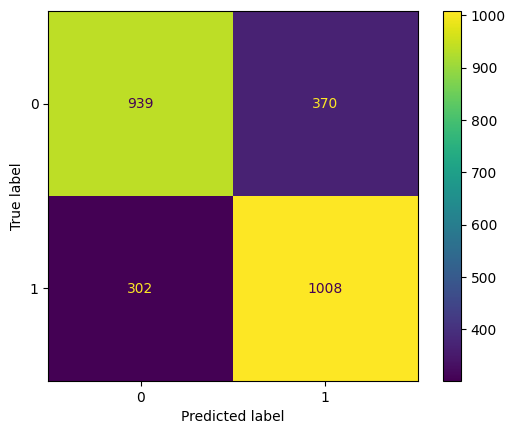

In [203]:
import sklearn

cm = sklearn.metrics.confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()